# 시간 설정

In [1]:
import time
import random
import os

os.environ['TZ'] = 'Asia/Seoul'
time.tzset()

random.seed(1490)

def print_time() -> None:
    print(time.strftime('%Y년 %m월 %d일 %A %p %I시 %M분 %S초'))
    return

print_time()

2024년 08월 26일 Monday PM 10시 32분 49초


In [2]:
def timestamp() -> str:
    return time.strftime('%Y-%m-%d-%H-%M-%S')

timestamp()

'2024-08-26-22-32-49'

# 제품 이상여부 판별 프로젝트


## 필수 라이브러리


In [3]:
import os
from pprint import pprint

import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn import metrics
from sklearn.model_selection import train_test_split
from tqdm import tqdm

from sklearn.preprocessing import LabelEncoder

import matplotlib.pyplot as plt  # 그래프 보기
import seaborn as sns  # 그래프 보기

from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler #Scaling

print_time()

2024년 08월 26일 Monday PM 10시 32분 51초


## 전역변수

In [4]:
# ROOT_PREFIX = "/content/drive/MyDrive/lgaimers5/" # 구글 드라이브용 루트
# ROOT_DIR = ROOT_PREFIX + "data" # 에이머스 제출 시 주석 처리 필요
ROOT_DIR = "data" # 구글 드라이브 실행 시 주석 처리 필요
RANDOM_STATE = 110 # 랜덤 시드
corr_thresh = 0.001 # 상관관계 삭제 기준

# 랜덤 시드 설정
np.random.seed(RANDOM_STATE)

# 1. 필터 1번, 필터 2번 등과 같이 순서가 있는 값은 추가 처리 없이 넘버링, 그 외 기타 order들도 같이 넘버링
numbering = ['Equipment_Dam', 'Model.Suffix_Dam', 'Workorder_Dam', 'Model.Suffix_AutoClave', 'Workorder_AutoClave', 'Equipment_Fill1', \
             'Model.Suffix_Fill1', 'Workorder_Fill1', 'Equipment_Fill2', 'Model.Suffix_Fill2', 'Workorder_Fill2']

# 2. OK, NG와 같이 범주형인 경우 가능하면 원 핫 인코딩
onehot = ['HEAD NORMAL COORDINATE X AXIS(Stage1) Judge Value_Dam', 'Chamber Temp. Judge Value_AutoClave', \
          'GMES_ORIGIN_INSP_JUDGE_CODE Collect Result_AutoClave', 'GMES_ORIGIN_INSP_JUDGE_CODE Judge Value_AutoClave', \
          'HEAD NORMAL COORDINATE X AXIS(Stage1) Judge Value_Fill1', 'HEAD NORMAL COORDINATE X AXIS(Stage1) Judge Value_Fill2']

# 3. 숫자 값이 들어가야 하는데 OK가 혼입된 값임
custom = ['HEAD NORMAL COORDINATE X AXIS(Stage1) Collect Result_Dam', 'HEAD NORMAL COORDINATE X AXIS(Stage1) Collect Result_Fill1', \
          'HEAD NORMAL COORDINATE X AXIS(Stage1) Collect Result_Fill2']

drops = [] # 값이 없거나 무의미해서 버릴 column들
need_general = []  # normalization list
del_list = [] # 상관관계 삭제 리스트

print_time()

2024년 08월 26일 Monday PM 10시 32분 51초


## 함수 정의

In [5]:
def print_col_uniqs(data, mode = 'train'):
    """
    unique 개수가 1개 이하인 column 삭제
    """
    if mode != 'train': # 테스트 데이터는 아래 과정 스킵
#         print(f'테스트 데이터 Set ID 삭제')
#         data.drop('Set ID', axis=1, inplace=True)
        print('속성 삭제')
        data.drop(drops, axis=1, inplace=True)
        # data.fillna(-1, inplace = True)
        for col in data.columns:
            if str(data[col].dtypes) != 'object':
                data[col] = data[col].fillna(data[col].mean())
            else:
                data[col].fillna(-1, inplace = True)
        print(f'결측값 처리 결과: {data.isna().sum().sum() - data["target"].isna().sum()}')
        return data, drops

    init_cols = len(data.columns)
    for col in data.columns:
        if col == 'target':
            continue
        uniqs = data[col].unique()
        nuq = data[col].nunique()
        vcnt = data[col].value_counts()
        if (nuq <= 1 and len(uniqs) <= 1) or (len(data) == data[col].isna().sum()):
            drops.append(col)
        else:
            if nuq <= 10:
                # print(f'{col} : {nuq}, {uniqs}')
                pass
            else:
                # print(f'{col} : {nuq}')
                pass

    data.drop(drops, axis=1, inplace=True)
    data.drop_duplicates(keep='first', inplace=True, ignore_index=True) # 중복 제거
    data[list(data.columns)].dropna(axis=0, inplace=True) # 모든 속성이 결측값인 행 제거
    
    # data.fillna(-1, inplace = True)
    for col in data.columns:
        if str(data[col].dtypes) != 'object':
            data[col] = data[col].fillna(data[col].mean())
        else:
            data[col].fillna(-1, inplace = True)
    print(f'결측값 처리 결과: {data.isna().sum().sum()}')
    print(f'\nnum of initial cols: {init_cols}')
    print(f'num of deleted cols: {len(drops)}')
    print(f'num of remained cols: {len(data.columns)}')
    return data, drops

def print_columns_to_list(data):
    """
    컬럼이 너무 많아 바로 출력이 안되니 직접 출력
    """
    cnt = {}
    for col in data.columns:
        dt = str(data[col].dtypes)
        nu = data[col].nunique()
        if dt in cnt.keys():
            cnt[dt] += 1
        else:
            cnt[dt] = 1
        print(f'* {col} : {dt}({nu})')
    print(f'\ninfo: {cnt}')

def object_unique(data):
    """
    dtype이 object로 분류된 컬럼의 unique 값 확인
    """
    idx = 1
    for col in data.columns:
        if str(data[col].dtypes) == 'object':
            print(f'{idx}. {col}\n\t{data[col].nunique()}', end='')
            if data[col].nunique() <= 20:
                print(f', {data[col].unique()}')
            else:
                print()
            idx += 1

def enc_numbering(data, cols):
    """
    단순 넘버링으로 라벨 인코딩
    """
    for col in cols:
        data[col] = data[col].astype(str)
        le = LabelEncoder()
        le.fit(sorted(list(data[col].unique())))
        data[col] = le.transform(data[col])
    return data

def enc_onehot(data, cols):
    """
    원 핫 인코딩
    """
    data = pd.get_dummies(data, columns = cols)
    return data

def enc_only_obj(data, cols):
    """
    다른 컬럼의 OK가 혼입된 값 정리, 소수 값을 리터럴 소수로 변환 후 dtype도 소수로 지정
    """
    for col in cols:
        idx = 1
        uniqs = data[col].unique()
        for u in uniqs:
            try:
                data.loc[data[col] == u, col] = float(u)
            except:
                if u == 'OK' or u == -1:
                    data.loc[data[col] == u, col] = -1
                else:
                    data.loc[data[col] == u, col] = idx
                    idx += 1
        data[col] = data[col].astype(float)
        # print(data[col])
    return data

def obj_encoding(data, mode = 'train'):
    """
    모든 라벨 인코딩 실행
    """
    # 기본 넘버링
    data = enc_numbering(data, numbering)
    # 원 핫 인코딩
    # data = enc_onehot(data, onehot)
    data = enc_numbering(data, onehot)
    # OK가 혼입된 값 정리
    data = enc_only_obj(data, custom)
    # target 인코딩
    # 있는 경우에만
    if mode == 'train':
        data.loc[data['target'] == 'AbNormal', 'target'] = 1
        data.loc[data['target'] == 'Normal', 'target'] = 0
    return data

def normalization(data, mode = 'train'):
    """
    각 컬럼의 왜도와 첨도를 계산하고 일정 값 이상일 경우 정규화 대상으로 저장 후 리스트 반환
    """
    # 테스트 데이터일 경우 기존의 리스트 그대로 반환
    if mode != 'train':
        return need_general

    kurts = data.kurtosis() # 첨도
    skews = data.skew() # 왜도

    for col in data.columns:
        if col == 'target':
            continue
        if data[col].min() == 0 and data[col].max() == 1: # 만약 최솟값이 0이고 최댓값이 1이라면 원 핫 인코딩된 컬럼일 수 있으므로 넘긴다
            continue
        kval = kurts[col]
        sval = skews[col]
        if (abs(kval) >= 10.0 or abs(sval) >= 10.0) and data[col].dtypes != bool:
            need_general.append(col)
            print(col, end='\t')
            print("kurt : {:.3f}\tskew : {:.3f}".format(kval, sval))

    # target은 혹시라도 조작하면 안되니까 리스트에 있다면 삭제
    if need_general.count('target') > 0:
        need_general.remove('target')

    print()
    print(need_general)
    return need_general

def do_general(data):
    """
    사전 저장된 리스트에 있는 컬럼들 모두 최대최소정규화
    """
    _before = {}
    _after = {}

    for col in need_general:
        mini = data[col].min()
        maxi = data[col].max()
        _before[col] = maxi - mini
        data[col] = (data[col] - float(mini)) / (maxi - float(mini))
        _after[col] = data[col].max() - data[col].min()

    print("data before and after")
    for cl in need_general:
        print(cl, end='\t')
        print("{}\t->\t{}".format(_before[cl], _after[cl]))

    return data

def show_heatmap(data, cnt = 12):
    """
    컬럼을 지정된 수만큼 묶어서 히트맵 출력
    * 색깔 참고: https://colorbrewer2.org/
    """
    cols = list(data.columns)
    corr = data.corr()
    print(corr.info())

    # plt.figure(figsize=(15, 10))
    # sns.heatmap(data.corr(), annot=True, cmap="RdBu", vmax=1)
    # plt.show()

def del_by_corr(data, thresh = 0.5, mode = 'train', del_list = []):
    """
    지정된 값을 기준으로 상관관계가 낮은 컬럼 삭제
    """
    # 테스트 데이터일 경우 기존 리스트로 바로 삭제
    if mode != 'train':
        data.drop(del_list, axis=1, inplace=True)
        return data, del_list

    corr = data.corr()
    target_corr = corr['target']
    target_corr.drop('target', inplace=True)
    del_list = list(target_corr[target_corr.isnull() == True].index)
    temp = target_corr[-thresh < target_corr]
    del_list += list(temp[temp < thresh].index)

    data.drop(del_list, axis=1, inplace=True)

    return data, del_list

def plot_and_scale(data):
    scaling_methods = {}
    for col in data.columns:
        if col == 'target':
            continue
        
        plt.figure(figsize=(10, 6))
        sns.histplot(data[col], kde=True)
        plt.title(f'Distribution of {col}')
        plt.show()
        
        # Determine scaling method based on distribution
        if abs(data[col].skew()) > 1 or abs(data[col].kurtosis()) > 10:  # many outliers or skewness
            scaler = RobustScaler()
            scaling_methods[col] = 'RobustScaler'
        elif abs(data[col].skew()) < 0.5:  # close to normal distribution
            scaler = StandardScaler()
            scaling_methods[col] = 'StandardScaler'
        else:  # uniform distribution or others
            scaler = MinMaxScaler()
            scaling_methods[col] = 'MinMaxScaler'
        
        # Apply the scaling
        data[col] = scaler.fit_transform(data[[col]])

    return data, scaling_methods


def pre_processing(data, mode='train', del_list=del_list):
    """
    데이터 전처리 통합 실행
    """
    # 데이터 뒤섞기
    if mode == 'train':
        print(f'# 데이터 뒤섞기')
        data = data.sample(frac=1)  # randomize data

    # unique 개수가 1개 이하인 column 삭제
    print('# unique 개수가 1개 이하인 column 삭제')
    data, drops = print_col_uniqs(data, mode)

    # 모든 라벨 인코딩 실행
    print('# 모든 라벨 인코딩 실행')
    data = obj_encoding(data, mode)

    # 상관관계가 낮은 컬럼 삭제
    print('# 상관관계가 낮은 컬럼 삭제')
    data, del_list = del_by_corr(data, thresh=corr_thresh, mode=mode, del_list=del_list)

    if mode == 'train':
        print('target 값 정수화')
        data['target'] = data['target'].astype(int)
    
    # Plot distributions and apply appropriate scaling
#     print('# Plotting distributions and applying scaling')
#     data, scaling_methods = plot_and_scale(data)
#     print(f'Scaling methods applied: {scaling_methods}')

    # 전처리 완료
    print('전처리 완료')

    return data, drops, del_list

print_time()

2024년 08월 26일 Monday PM 10시 32분 51초


## 1. 데이터 불러오기


### 데이터 읽어오기


In [6]:
print_time()

# Load data
train_data = pd.read_csv(os.path.join(ROOT_DIR, "train.csv"))

# 데이터 전처리
train_data, drops, del_list = pre_processing(train_data)

2024년 08월 26일 Monday PM 10시 32분 51초
# 데이터 뒤섞기
# unique 개수가 1개 이하인 column 삭제
결측값 처리 결과: 0

num of initial cols: 464
num of deleted cols: 313
num of remained cols: 151
# 모든 라벨 인코딩 실행
# 상관관계가 낮은 컬럼 삭제
target 값 정수화
전처리 완료


In [7]:
print(len(drops), len(del_list))

313 3


### columns info

In [8]:
# 전체 컬럼 정보 출력
print_columns_to_list(train_data)

* Equipment_Dam : int64(2)
* Model.Suffix_Dam : int64(7)
* Workorder_Dam : int64(663)
* CURE END POSITION X Collect Result_Dam : float64(2)
* CURE END POSITION Z Collect Result_Dam : float64(2)
* CURE END POSITION Θ Collect Result_Dam : int64(2)
* CURE SPEED Collect Result_Dam : int64(5)
* CURE START POSITION X Collect Result_Dam : int64(2)
* CURE START POSITION Θ Collect Result_Dam : int64(2)
* DISCHARGED SPEED OF RESIN Collect Result_Dam : int64(3)
* DISCHARGED TIME OF RESIN(Stage1) Collect Result_Dam : float64(19)
* DISCHARGED TIME OF RESIN(Stage2) Collect Result_Dam : float64(29)
* DISCHARGED TIME OF RESIN(Stage3) Collect Result_Dam : float64(20)
* Dispense Volume(Stage1) Collect Result_Dam : float64(23)
* Dispense Volume(Stage2) Collect Result_Dam : float64(33)
* Dispense Volume(Stage3) Collect Result_Dam : float64(22)
* HEAD NORMAL COORDINATE X AXIS(Stage1) Collect Result_Dam : float64(7)
* HEAD NORMAL COORDINATE X AXIS(Stage1) Judge Value_Dam : int64(2)
* HEAD NORMAL COORDINATE 

### object uniques

In [9]:
# object 데이터의 unique 값 확인
object_unique(train_data)

print_time()

2024년 08월 26일 Monday PM 10시 32분 55초


In [10]:
# info 확인
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40506 entries, 0 to 40505
Columns: 148 entries, Equipment_Dam to target
dtypes: float64(70), int64(78)
memory usage: 45.7 MB


In [11]:
train_data.isna().sum().sum()

0

In [12]:
# 컬럼 리스트 확인
# 리스트로 변환하면 생략하지 않고 출력됨
list(train_data.columns)

['Equipment_Dam',
 'Model.Suffix_Dam',
 'Workorder_Dam',
 'CURE END POSITION X Collect Result_Dam',
 'CURE END POSITION Z Collect Result_Dam',
 'CURE END POSITION Θ Collect Result_Dam',
 'CURE SPEED Collect Result_Dam',
 'CURE START POSITION X Collect Result_Dam',
 'CURE START POSITION Θ Collect Result_Dam',
 'DISCHARGED SPEED OF RESIN Collect Result_Dam',
 'DISCHARGED TIME OF RESIN(Stage1) Collect Result_Dam',
 'DISCHARGED TIME OF RESIN(Stage2) Collect Result_Dam',
 'DISCHARGED TIME OF RESIN(Stage3) Collect Result_Dam',
 'Dispense Volume(Stage1) Collect Result_Dam',
 'Dispense Volume(Stage2) Collect Result_Dam',
 'Dispense Volume(Stage3) Collect Result_Dam',
 'HEAD NORMAL COORDINATE X AXIS(Stage1) Collect Result_Dam',
 'HEAD NORMAL COORDINATE X AXIS(Stage1) Judge Value_Dam',
 'HEAD NORMAL COORDINATE X AXIS(Stage3) Collect Result_Dam',
 'HEAD NORMAL COORDINATE Y AXIS(Stage1) Collect Result_Dam',
 'HEAD NORMAL COORDINATE Y AXIS(Stage2) Collect Result_Dam',
 'HEAD NORMAL COORDINATE Y AXI

### ADASYN 오버 샘플링

https://dapin1490.github.io/satinbower/posts/it-deeplearning-data-2/#3-adasyn-%EC%98%A4%EB%B2%84-%EC%83%98%ED%94%8C%EB%A7%81

In [13]:
!pip install imblearn

Defaulting to user installation because normal site-packages is not writeable


In [14]:
import imblearn  # 샘플링 관련 라이브러리
print("\nimblearn 버전 확인\n{}".format(imblearn.__version__))

# ADASYN 오버 샘플링
# 참고 https://dining-developer.tistory.com/27
from imblearn.over_sampling import ADASYN

temp_x = train_data.drop('target', axis=1)
temp_y = train_data['target']

temp_x, temp_y = ADASYN(sampling_strategy=0.3).fit_resample(temp_x, temp_y)

df_concat = pd.concat([temp_x, temp_y], axis=1).reset_index(drop=True)
df_concat.value_counts('target')


imblearn 버전 확인
0.12.3


target
0    38156
1    11057
Name: count, dtype: int64

### 언더 샘플링


데이타 불균형을 해결하기 위해 언더 샘플링을 진행합니다.


In [15]:
normal_ratio = 3.2  # 1.0 means 1:1 ratio # 최대 16.24

df_normal = df_concat[df_concat["target"] == 0]
df_abnormal = df_concat[df_concat["target"] == 1]

num_normal = len(df_normal)
num_abnormal = len(df_abnormal)
print(f"Total: Normal: {num_normal}, AbNormal: {num_abnormal}")

df_normal = df_normal.sample(n=int(num_abnormal * normal_ratio), replace=False, random_state=RANDOM_STATE)
df_concat = pd.concat([df_normal, df_abnormal], axis=0).reset_index(drop=True)
print(df_concat.value_counts("target"))

print()
print_time()

Total: Normal: 38156, AbNormal: 11057
target
0    35382
1    11057
Name: count, dtype: int64

2024년 08월 26일 Monday PM 10시 33분 04초


### 데이터 분할


In [16]:
print_time()
print()

df_train, df_val = train_test_split(
    df_concat,
    test_size=0.2,
    stratify=df_concat["target"],
    random_state=RANDOM_STATE,
)


def print_stats(df: pd.DataFrame):
    num_normal = len(df[df["target"] == 0])
    num_abnormal = len(df[df["target"] == 1])

    print(f"  Total: Normal: {num_normal}, AbNormal: {num_abnormal}" + f" ratio: {num_abnormal/num_normal}")


# Print statistics
print(f"  \tNormal    \tAbNormal")
print_stats(df_train)
print_stats(df_val)

2024년 08월 26일 Monday PM 10시 33분 04초

  	Normal    	AbNormal
  Total: Normal: 28305, AbNormal: 8846 ratio: 0.3125242889948772
  Total: Normal: 7077, AbNormal: 2211 ratio: 0.31242051716829167


In [17]:
features = []

for col in df_train.columns:
    try:
        # df_train[col] =
        df_train[col].astype(int) # float를 그대로 두기 위해 일부러 줄을 내렸으나, object 컬럼을 제외한다는 것은 유지하기 위해 이 부분은 놔둠
        features.append(col)
    except:
        continue

if 'target' in features:
    features.remove('target')

train_x = df_train[features]
train_y = df_train["target"]

print_time()
train_x.info()

2024년 08월 26일 Monday PM 10시 33분 04초
<class 'pandas.core.frame.DataFrame'>
Index: 37151 entries, 14349 to 22311
Columns: 147 entries, Equipment_Dam to WorkMode Collect Result_Fill2
dtypes: float64(70), int64(77)
memory usage: 41.9 MB


In [18]:
# 학습 데이터 기준으로 f1 score 채점
test_x = df_val[features]
test_y = df_val["target"]
pred_y = []

print_time()

2024년 08월 26일 Monday PM 10시 33분 05초


In [19]:
from sklearn.preprocessing import StandardScaler

# Standard Scaling
scaler = StandardScaler()

train_x_scaled = scaler.fit_transform(train_x)
test_x_scaled = scaler.transform(test_x)

print_time()
train_data.info()

2024년 08월 26일 Monday PM 10시 33분 05초
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40506 entries, 0 to 40505
Columns: 148 entries, Equipment_Dam to target
dtypes: float64(70), int64(78)
memory usage: 45.7 MB


## 3. 모델 학습


### 모델 정의


In [20]:
!pip install --upgrade pip
!pip install xgboost
!pip install lightgbm
!pip install catboost

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


In [31]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB, CategoricalNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

models = {}

# K최근접이웃
knn1 = KNeighborsClassifier(n_neighbors=12, weights='distance', p=1)
knn2 = KNeighborsClassifier(n_neighbors=20, weights='distance', p=1)
knn3 = KNeighborsClassifier(n_neighbors=2, weights='distance', p=1)
knn4 = KNeighborsClassifier(n_neighbors=8, weights='distance', p=1)
knn5 = KNeighborsClassifier(n_neighbors=16, weights='distance', p=1)

from sklearn.ensemble import VotingClassifier

models['V_clf'] = VotingClassifier( estimators=[('KNN1',knn1),('KNN2',knn2),('KNN3',knn3),('KNN4',knn4),('KNN5',knn5)] , voting='soft' )


print_time()

2024년 08월 26일 Monday PM 10시 37분 45초


### knn 학습 결과  
https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html

***************************

- **`n_neighbors=3`**
- 정확도: 0.5798
- precision: [0.5770 0.5828]
- recall: [0.5979 0.5617]
- f1 score: [0.5873 0.5720]
- **knn predicted 43.23% AbNormal**

***

- **`n_neighbors=3, weights='distance'`**

**********************************************************************************************

### dt 학습 결과  
https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html

***************************

- **`random_state=RANDOM_STATE`**
- 정확도: 1.0000
- precision: [1.0000 1.0000]
- recall: [1.0000 1.0000]
- f1 score: [1.0000 1.0000]
- **dt predicted 0.0% AbNormal**

***

- **`random_state=RANDOM_STATE, splitter='random'`**

**********************************************************************************************

### nb 학습 결과  
https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.GaussianNB.html

***************************

- **`default`**
- 정확도: 0.9500
- precision: [0.9976 0.9107]
- recall: [0.9021 0.9979]
- f1 score: [0.9475 0.9523]
- **nb predicted 0.0% AbNormal**

***

- **`var_smoothing=1e-10`**

**********************************************************************************************

### svm 학습 결과  
https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html

***************************

- **`kernel='linear', random_state=RANDOM_STATE, verbose=True`**
- 정확도: 0.8936
- precision: [0.9744 0.8364]
- recall: [0.8085 0.9787]
- f1 score: [0.8837 0.9020]
- **svm predicted 0.86% AbNormal**

***

- **`kernel='poly', random_state=RANDOM_STATE, verbose=False`**

**********************************************************************************************

### rf 학습 결과  
https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html

***************************

- **`n_estimators=100, random_state=RANDOM_STATE, verbose=1`**
- 정확도: 1.0000
- precision: [1.0000 1.0000]
- recall: [1.0000 1.0000]
- f1 score: [1.0000 1.0000]
- **rf predicted 0.22% AbNormal**

***

- **`n_estimators=70, random_state=RANDOM_STATE, verbose=1`**

**********************************************************************************************

### xgb 학습 결과
https://xgboost.readthedocs.io/en/stable/python/python_api.html#xgboost.XGBClassifier  
https://xgboost.readthedocs.io/en/stable/python/python_api.html#xgboost.callback.TrainingCallback  
https://xgboost.readthedocs.io/en/stable/python/python_api.html#xgboost.XGBClassifier.load_model  

***************************

- **`eval_metric='mlogloss', random_state=RANDOM_STATE`**
- 정확도: 1.0000
- precision: [1.0000 1.0000]
- recall: [1.0000 1.0000]
- f1 score: [1.0000 1.0000]
- **xgb predicted 0.0% AbNormal**

***

- **`num_classes=2, eval_metric='mlogloss', random_state=RANDOM_STATE, verbosity = 1`**

**********************************************************************************************

### lgb 학습 결과
https://lightgbm.readthedocs.io/en/latest/pythonapi/lightgbm.LGBMClassifier.html

***************************

- **`random_state=42`**
- 정확도: 1.0000
- precision: [1.0000 1.0000]
- recall: [1.0000 1.0000]
- f1 score: [1.0000 1.0000]
- **lgb predicted 0.0% AbNormal**

***

- **`boosting_type = 'dart', objective = 'binary', boost_from_average = False, random_state=RANDOM_STATE`**

**********************************************************************************************

### catb 학습 결과
https://catboost.ai/en/docs/concepts/python-reference_catboostclassifier

***************************

- **`iterations=1000, learning_rate=0.1, depth=6, random_state=42, verbose=0`**
- 정확도: 1.0000
- precision: [1.0000 1.0000]
- recall: [1.0000 1.0000]
- f1 score: [1.0000 1.0000]
- **catb predicted 0.0% AbNormal**

***

- **`iterations=1000, learning_rate=0.1, depth=6, random_state=RANDOM_STATE, verbose=1`**

### 모델 학습


In [32]:
test_x.shape

(9288, 147)

In [33]:
test_y.shape

(9288,)

In [34]:
for name in models.keys():
    print(f'{name} training...')
    start = time.time()
    if name == 'xgb':
        models[name].fit(train_x, train_y, eval_set=[(test_x, test_y)], verbose = True)
    else:
        models[name].fit(train_x, train_y)
    end = time.time()
    print(f'{name} trained {(end - start) :.2f}s')
    print()

V_clf training...
V_clf trained 0.27s



### 기록 확인

V_clf 학습 결과
***************************
- 정확도: 0.8713
- precision: 0.7459
- recall: 0.6970
- f1 score: 0.7206
precision과 recall의 차이: 0.0489

V_clf 학습 결과
분류 결과:
              precision    recall  f1-score   support

      Normal       0.91      0.93      0.92      7077
    AbNormal       0.75      0.70      0.72      2211

    accuracy                           0.87      9288
   macro avg       0.83      0.81      0.82      9288
weighted avg       0.87      0.87      0.87      9288

혼동 행렬:
[[0.92581602 0.07418398]
 [0.3030303  0.6969697 ]]


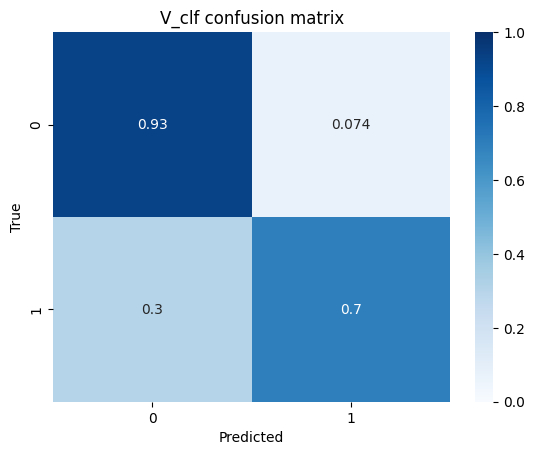

In [35]:
preds = {}

for name in models.keys():
    preds[name] = models[name].predict(test_x)
    
    prec = precision_score(test_y, preds[name], average=None)
    recall = recall_score(test_y, preds[name], average=None)
    f1score = f1_score(test_y, preds[name], average=None)
    
    print(f"{name} 학습 결과\n***************************")
    print(f"- 정확도: {accuracy_score(test_y, preds[name]) :.4f}")
    print(f"- precision: {prec[1] :.4f}")
    print(f"- recall: {recall[1] :.4f}")
    print(f"- f1 score: {f1score[1] :.4f}")
    print(f'precision과 recall의 차이: {prec[1] - recall[1] :.4f}')
    print()
    
    confu_mat = confusion_matrix(test_y, preds[name], normalize='true')
    
    print(f"{name} 학습 결과\n===========================")
    print(f"분류 결과:\n{classification_report(test_y, preds[name], target_names=['Normal', 'AbNormal'])}")
    print(f"혼동 행렬:\n{confu_mat}")
    sns.heatmap(confu_mat, annot=True, cmap='Blues', vmax = 1, vmin = 0)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(f'{name} confusion matrix')
    plt.show()
    print()

## 4. 제출하기


### 테스트 데이터 예측


테스트 데이터 불러오기


In [36]:
print(len(drops), len(del_list))

313 3


In [37]:
# 기본 코드 그대로
test_data = pd.read_csv(os.path.join(ROOT_DIR, "test.csv"))
test_data.drop('Set ID', axis=1, inplace=True)
test_data, temp, temp = pre_processing(data = test_data, mode = 'test', del_list = del_list)

print_time()
test_data.info()

# unique 개수가 1개 이하인 column 삭제
속성 삭제
결측값 처리 결과: 0
# 모든 라벨 인코딩 실행
# 상관관계가 낮은 컬럼 삭제
전처리 완료
2024년 08월 26일 Monday PM 10시 42분 11초
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17361 entries, 0 to 17360
Columns: 148 entries, Equipment_Dam to target
dtypes: float64(71), int64(77)
memory usage: 19.6 MB


In [38]:
test_data.isna().sum().sum() - test_data['target'].isna().sum()

0

In [39]:
df_test_x = test_data[features]

# 학습 데이터와 동일하게 정수화 안 함
# for col in df_test_x.columns:
#     try:
#         df_test_x.loc[:, col] = df_test_x[col].astype(int)
#     except:
#         continue

print_time()
test_data.info()

2024년 08월 26일 Monday PM 10시 42분 12초
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17361 entries, 0 to 17360
Columns: 148 entries, Equipment_Dam to target
dtypes: float64(71), int64(77)
memory usage: 19.6 MB


In [40]:
models.keys()

dict_keys(['V_clf'])

In [41]:
test_preds = {}

for name in models.keys():
    test_preds[name] = models[name].predict(df_test_x)
    print(f'{name} predicted {round(sum(test_preds[name]) / len(test_preds[name]) * 100, 2)}% AbNormal')
    print()

V_clf predicted 8.25% AbNormal



- svm  
    **svm predicted 0.86% AbNormal**  
    score: 0.06206896551724138  
    **svm predicted 24.87% AbNormal**  
    Public Score : 0.13885778275475924  

In [42]:
print_time()

# 제출용 모델 이름만 골라서 넣으면 됨
test_pred = models['V_clf'].predict(df_test_x)

print(f'{round(sum(test_pred) / len(test_pred) * 100, 2)}% AbNormal')

test_pred

2024년 08월 26일 Monday PM 10시 45분 30초
8.25% AbNormal


array([0, 0, 0, ..., 1, 0, 0])

### 제출 파일 작성


In [43]:
# 제출 데이터 읽어오기 (df_test는 전처리된 데이터가 저장됨)
# df_sub = pd.read_csv(ROOT_PREFIX + "submission.csv") # 에이머스 제출 시 주석 처리 필요
df_sub = pd.read_csv("submission.csv") # 구글 드라이브 실행 시 주석 처리 필요
df_sub["target"] = test_pred
df_sub.loc[df_sub['target'] >= 0.5, 'target'] = 1
df_sub.loc[df_sub['target'] < 0.5, 'target'] = 0

print(f"{sum(df_sub['target']) / len(df_sub['target']) * 100 :.2f}% AbNormal")

df_sub['target'] = df_sub['target'].astype(str)
df_sub.loc[df_sub['target'] == '1', 'target'] = 'AbNormal'
df_sub.loc[df_sub['target'] == '0', 'target'] = 'Normal'

print_time()

8.25% AbNormal
2024년 08월 26일 Monday PM 10시 48분 16초


In [44]:
print_time()

df_sub.head(10)

2024년 08월 26일 Monday PM 10시 48분 16초


,Set ID,target
0,0001be084fbc4aaa9d921f39e595961b,Normal
1,0005bbd180064abd99e63f9ed3e1ac80,Normal
2,000948934c4140d883d670adcb609584,Normal
3,000a6bfd02874c6296dc7b2e9c5678a7,Normal
4,0018e78ce91343678716e2ea27a51c95,Normal
5,001fda4596f545d0a3b0ce85fbea77d2,Normal
6,0020734a7b29472298358ad58645a0c9,Normal
7,00234c5914cd4c4a888d13f8b3773135,Normal
8,00297b6c93e44d49ac534758a23dc74e,Normal
9,002d904240d84b188d410d16383a9c3a,Normal


In [45]:
# 제출 파일 저장
# df_sub.to_csv(ROOT_PREFIX + "submission.csv", index=False) # 에이머스 제출 시 주석 처리 필요
df_sub.to_csv("submission.csv", index=False) # 구글 코랩 실행 시 주석 처리 필요

print_time()

2024년 08월 26일 Monday PM 10시 48분 16초


**우측 상단의 제출 버튼을 클릭해 결과를 확인하세요**
